# 1. Libraries

In [1]:
# Libraries for the model

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import a random rf classifier
from sklearn.ensemble import RandomForestClassifier
# Import a Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 2. Loading the preprocessed data

In [2]:
# For the male model
X_train_male = pd.read_csv('../Data/Train/Xmale_train.csv')
y_train_male = pd.read_csv('../Data/Train/ymale_train.csv')
X_test_male = pd.read_csv('../Data/Test/Xmale_test.csv')
y_test_male = pd.read_csv('../Data/Test/ymale_test.csv')

In [3]:
# For the female model
X_train_fem = pd.read_csv('../Data/Train/Xfemale_train.csv')
y_train_fem = pd.read_csv('../Data/Train/yfemale_train.csv')
X_test_fem = pd.read_csv('../Data/Test/Xfemale_test.csv')
y_test_fem = pd.read_csv('../Data/Test/yfemale_test.csv')

In [4]:
# All data
df = pd.read_csv('../Data/Titanic-Dataset.csv')
df = df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']]

We are going to use the same model for both Male and Female, but each will be trained with their corresponding sets. However, we will implement a RandomForest, but also a Logistic Regression.

# 3. T-Learner implementation (Random Forest)

## 3.1. Male model

In [5]:
X_train_fem.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Fare_scaled'], dtype='object')

In [6]:
# Let's do a GridSearch for the best parameters

# Define the base model
rf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 150, 200, 250],
    'max_depth': [5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# For the random forest we are not going to use Fare_scaled
rf_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# Fit the grid search (use your training data)
grid_search.fit(X_train_male[rf_cols], y_train_male)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best Score: 0.7707666587055171


c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [7]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    # Collect metrics
    metrics = {
        'Accuracy': [
            accuracy_score(y_train, y_train_pred),
            accuracy_score(y_test, y_test_pred)
        ],
        'Precision': [
            precision_score(y_train, y_train_pred, average='binary'),
            precision_score(y_test, y_test_pred, average='binary')
        ],
        'Recall': [
            recall_score(y_train, y_train_pred, average='binary'),
            recall_score(y_test, y_test_pred, average='binary')
        ],
        'F1-Score': [
            f1_score(y_train, y_train_pred, average='binary'),
            f1_score(y_test, y_test_pred, average='binary')
        ],
        'ROC AUC': [
            roc_auc_score(y_train, y_train_prob),
            roc_auc_score(y_test, y_test_prob)
        ]
    }

    # Create dataframe to show side-by-side
    metrics_df = pd.DataFrame(metrics, index=['Train', 'Test'])
    print("\nModel Evaluation Metrics (Train vs Test):\n")
    print(metrics_df)

    # Classification Reports
    print("\nClassification Report - Train:\n", classification_report(y_train, y_train_pred))
    print("\nClassification Report - Test:\n", classification_report(y_test, y_test_pred))

    # Confusion matrix - Train
    cm_train = confusion_matrix(y_train, y_train_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title("Confusion Matrix - Train Set")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Confusion matrix - Test
    cm_test = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Positive'], 
                yticklabels=['Negative', 'Positive'])
    plt.title("Confusion Matrix - Test Set")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


Model Evaluation Metrics (Train vs Test):

       Accuracy  Precision    Recall  F1-Score   ROC AUC
Train  0.841310   0.881690  0.788413  0.832447  0.943582
Test   0.862069   0.590909  0.812500  0.684211  0.900528

Classification Report - Train:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       397
           1       0.88      0.79      0.83       397

    accuracy                           0.84       794
   macro avg       0.85      0.84      0.84       794
weighted avg       0.85      0.84      0.84       794


Classification Report - Test:
               precision    recall  f1-score   support

           0       0.95      0.87      0.91        71
           1       0.59      0.81      0.68        16

    accuracy                           0.86        87
   macro avg       0.77      0.84      0.80        87
weighted avg       0.89      0.86      0.87        87



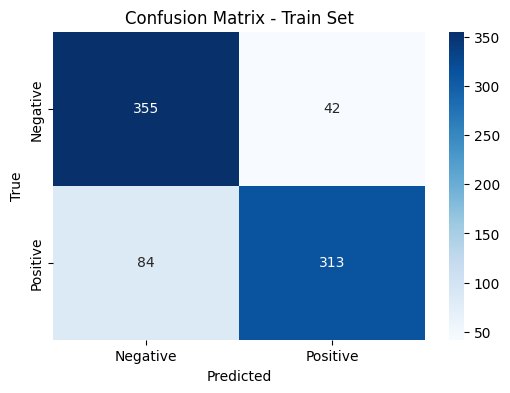

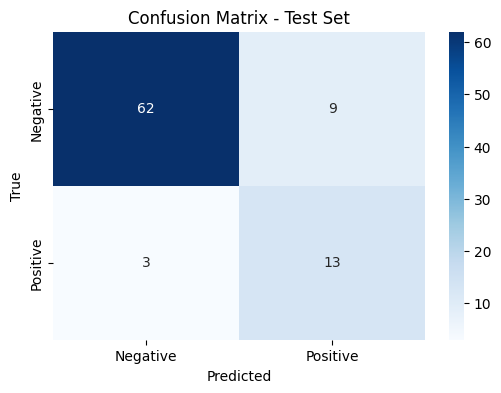

In [8]:
# Evaluate the model using the function we defined
best_rf_model = grid_search.best_estimator_
evaluate_model(best_rf_model, X_train_male[rf_cols], y_train_male, X_test_male[rf_cols], y_test_male)

## 3.2. Female model

c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Model Evaluation Metrics (Train vs Test):

       Accuracy  Precision    Recall  F1-Score   ROC AUC
Train  0.911168   0.965517  0.852792  0.905660  0.978922
Test   0.750000   0.961538  0.694444  0.806452  0.888889

Classification Report - Train:
               precision    recall  f1-score   support

           0       0.87      0.97      0.92       197
           1       0.97      0.85      0.91       197

    accuracy                           0.91       394
   macro avg       0.92      0.91      0.91       394
weighted avg       0.92      0.91      0.91       394


Classification Report - Test:
               precision    recall  f1-score   support

           0       0.50      0.92      0.65        12
           1       0.96      0.69      0.81        36

    accuracy                           0.75        48
   macro avg       0.73      0.81      0.73        48
weighted avg       0.85      0.75      0.77        48



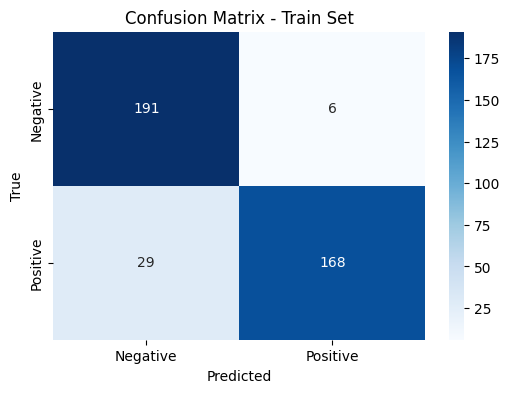

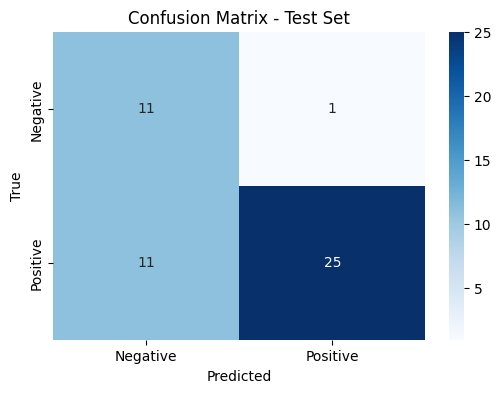

In [9]:
female_rf = RandomForestClassifier(random_state=42, class_weight='balanced', **grid_search.best_params_)
female_rf.fit(X_train_fem[rf_cols], y_train_fem)
evaluate_model(female_rf, X_train_fem[rf_cols], y_train_fem, X_test_fem[rf_cols], y_test_fem)

# 4. T-Learner (Logistic Regression)

## 4.1. Male model

In [10]:
# Let's do a GridSearch for the best parameters

# Define the base model
log_reg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Define the parameter grid
param_grid = {
    'solver': ['liblinear', 'saga'],            # Solvers that support l1 and l2
    'penalty': ['l1', 'l2'],                    # Regularization types
    'C': [0.001, 0.01, 0.1, 1, 10, 100],        # Wider range of regularization strength
    'fit_intercept': [True]            # Try with and without intercept
}

# Set up the GridSearchCV
grid_search = GridSearchCV(estimator=log_reg,
                           param_grid=param_grid,
                           cv=5,
                           scoring='accuracy',
                           n_jobs=-1,
                           verbose=2)

# Specify the LR columns
lr_cols = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare_scaled']

# Fit the grid search (use your training data)
grid_search.fit(X_train_male[lr_cols], y_train_male)

# Print the best parameters
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'C': 1, 'fit_intercept': True, 'penalty': 'l2', 'solver': 'liblinear'}
Best Score: 0.6776291696520976


c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



Model Evaluation Metrics (Train vs Test):

       Accuracy  Precision    Recall  F1-Score   ROC AUC
Train  0.683879   0.708571  0.624685  0.663989  0.729362
Test   0.781609   0.444444  0.750000  0.558140  0.875000

Classification Report - Train:
               precision    recall  f1-score   support

           0       0.66      0.74      0.70       397
           1       0.71      0.62      0.66       397

    accuracy                           0.68       794
   macro avg       0.69      0.68      0.68       794
weighted avg       0.69      0.68      0.68       794


Classification Report - Test:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85        71
           1       0.44      0.75      0.56        16

    accuracy                           0.78        87
   macro avg       0.69      0.77      0.71        87
weighted avg       0.84      0.78      0.80        87



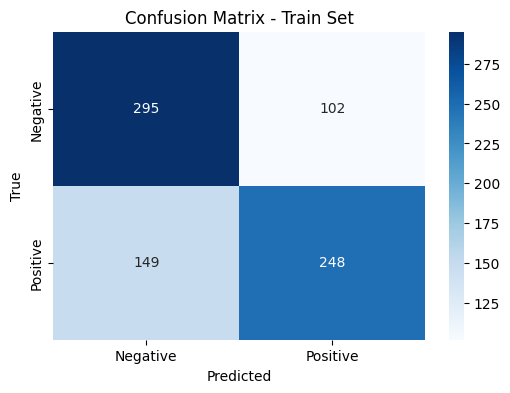

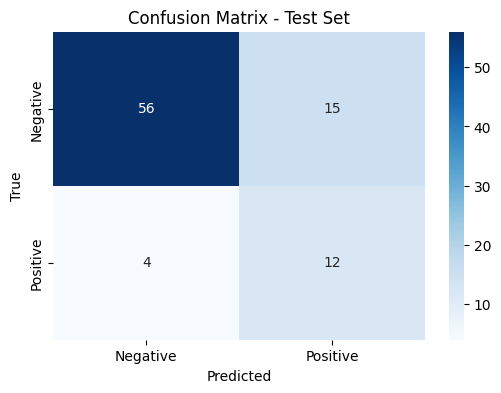

In [11]:
# Evaluate the model using the function we defined
best_log_reg = grid_search.best_estimator_
evaluate_model(best_log_reg, X_train_male[lr_cols], y_train_male, X_test_male[lr_cols], y_test_male)

## 4.2. Female model

In [12]:
log_reg_female = LogisticRegression(class_weight='balanced', 
                                    random_state=42, 
                                    max_iter=1000, 
                                    **grid_search.best_params_)

log_reg_female.fit(X_train_fem[lr_cols], y_train_fem)

c:\Users\sebas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')


Model Evaluation Metrics (Train vs Test):

       Accuracy  Precision    Recall  F1-Score   ROC AUC
Train  0.761421   0.815951  0.675127  0.738889  0.813394
Test   0.750000   1.000000  0.666667  0.800000  0.900463

Classification Report - Train:
               precision    recall  f1-score   support

           0       0.72      0.85      0.78       197
           1       0.82      0.68      0.74       197

    accuracy                           0.76       394
   macro avg       0.77      0.76      0.76       394
weighted avg       0.77      0.76      0.76       394


Classification Report - Test:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67        12
           1       1.00      0.67      0.80        36

    accuracy                           0.75        48
   macro avg       0.75      0.83      0.73        48
weighted avg       0.88      0.75      0.77        48



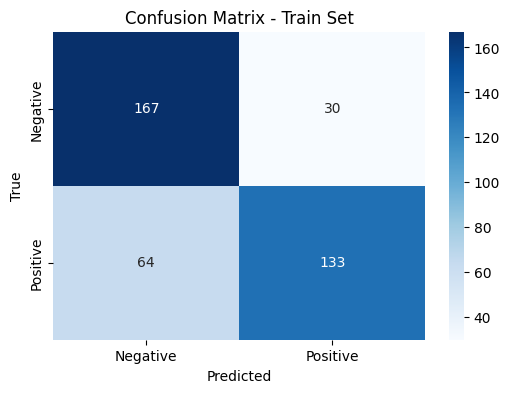

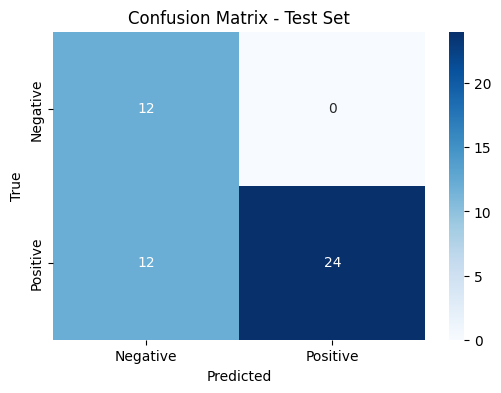

In [13]:
evaluate_model(log_reg_female, X_train_fem[lr_cols], y_train_fem, X_test_fem[lr_cols], y_test_fem)

# 5. ATE

In [14]:
df = df.dropna()
gender = df['Sex'] 
df['Fare_scaled'] = np.sqrt(df['Fare'])

# Modelo de Random Forest
y_hat_male = best_rf_model.predict_proba(df.drop(columns=['Sex', 'Fare_scaled']))[:, 1]
y_hat_female = female_rf.predict_proba(df.drop(columns=['Sex', 'Fare_scaled']))[:, 1]

# Modelo de regresión logística
y_hat_male_lr = best_log_reg.predict_proba(df.drop(columns=['Sex', 'Fare']))[:, 1]
y_hat_female_lr = log_reg_female.predict_proba(df.drop(columns=['Sex', 'Fare']))[:, 1]

In [15]:

# Diferencia individual según género real
effect = np.where(gender == 'male',
                  y_hat_male - y_hat_female,
                  y_hat_female - y_hat_male)

In [16]:
# ATE (Average Treatment Effect)
ate = effect.mean()
print(f"ATE (average effect of gender-based models in RF): {ate:.4f}")

ATE (average effect of gender-based models in RF): -0.0076


In [17]:

# Diferencia individual según género real
effect = np.where(gender == 'male',
                  y_hat_male_lr - y_hat_female_lr,
                  y_hat_female_lr - y_hat_male_lr)

# ATE (Average Treatment Effect)
ate = effect.mean()
print(f"ATE (average effect of gender-based models in LR): {ate:.4f}")

ATE (average effect of gender-based models in LR): -0.0185


# 6. Conclusions

In this project, I set out to explore the average effect of gender on survival outcomes using the Titanic dataset. To do this, I implemented the T-Learner methodology, training separate machine learning models for men and women. The models chosen were Random Forest and Logistic Regression, and before training, I carefully preprocessed the data by imputing missing values in the Age column using an Iterative Imputer and scaling the Fare variable.

Once the models were trained, I used them to predict survival probabilities for all individuals, regardless of gender. This allowed me to estimate the individual treatment effect by comparing the predictions of the male and female models. The average of these differences gave me the ATE (Average Treatment Effect). For the Random Forest models, the ATE was -0.0076, and for the Logistic Regression models, it was -0.0185.

Both ATE values are negative, indicating that, on average, individuals—regardless of their gender—are predicted to have slightly higher survival probabilities when evaluated using the female-trained model. In other words, the female model tends to be a bit more optimistic in predicting survival outcomes.

However, it’s important to note that these differences are not large. The effect sizes are relatively small, which suggests that while there is a pattern, it is subtle rather than dramatic.

In conclusion, both models hint at a modest survival advantage under the female-trained model, echoing the historically observed "women and children first" pattern from the Titanic disaster. This analysis highlights how causal inference methods like the T-Learner can quantify nuanced effects in widely studied datasets, and how model architecture and training groups can subtly influence predictive outcomes.